<a href="https://colab.research.google.com/github/LindaN731/Investment-Memo-ffr-deposit/blob/main/deposit_beta_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

"""
Deposit Beta Project - Summary Statistics
==========================================
根据数据描述生成描述性统计表格
"""

import pandas as pd
import numpy as np

# ============================================================
# 1. 读取数据（把路径改成你自己的文件路径）
# ============================================================


df = pd.read_csv("/content/deposit_beta_data.csv")

# Convert 'date' column to datetime objects
df['date'] = pd.to_datetime(df['date'])

print(f"数据形状: {df.shape}")
print(f"列名: {df.columns.tolist()}")


# ============================================================
# 2. 定义要统计的变量（分组展示更清晰）
# ============================================================

# 核心回归变量
regression_vars = {
    "depositratechange": "∆ Deposit Rate",
    "ffrchange":     "∆ Fed Funds Rate",
    "depositrate":    "Deposit Rate",
}

# 控制变量（滞后一期，用于回归）
control_vars = {
    "lassetslag": "Bank Size (lag)",
    "niblag":   "NIB Ratio (lag)",
    "roalag":   "ROA (lag)",
    "leveragelag": "Leverage Ratio (lag)",
    "loanlag":   "Loan Ratio (lag)",
    "liquiditylag": "Liquidity Ratio (lag)"
}
#Size — 大银行定价能力更强，对利率变化反应可能不同
#NIB Ratio — 非利息存款越多，银行对存款利率越不敏感（这部分客户本来就不拿利息）
#ROA — 盈利能力强的银行可能不需要靠高利率来吸引存款
#Leverage — 资本越充足，银行越稳健，行为可能不同
#Loan Ratio — 贷款多的银行更需要存款来融资，可能更积极跟进利率
#Liquidity — 流动性高的银行不缺钱，不需要用高利率吸引存款



# 原始水平变量（可选，便于理解数据）
level_vars = {
    "lassets":    "Bank Size",
    "nib":        "NIB Ratio",
    "roa":        "ROA",
    "leverage":   "Leverage Ratio",
    "loan":       "Loan Ratio",
    "liquidity":  "Liquidity Ratio",
}

all_vars = {**regression_vars, **control_vars, **level_vars}


# ============================================================
# 3. 生成描述性统计表
# ============================================================

def make_summary_table(df, var_dict, title="Summary Statistics"):
    """
    生成描述性统计表，包含：
    N, Mean, Std Dev, Min, P25, Median, P75, Max
    """
    rows = []

    for col, label in var_dict.items():
        if col not in df.columns:
            print(f"⚠️  警告：找不到列 '{col}'，已跳过")
            continue

        s = df[col].dropna()
        row = {
            "Variable": label,
            "N":    int(s.count()),
            "Mean":   s.mean(),
            "Std Dev": s.std(),
            "Min":    s.min(),
            "P25":    s.quantile(0.25),
            "Median":   s.median(),
            "P75":    s.quantile(0.75),
            "Max":     s.max(),
        }
        rows.append(row)

    summary = pd.DataFrame(rows).set_index("Variable")
    return summary


# 生成完整统计表
summary = make_summary_table(df, all_vars)

# ============================================================
# 4. 格式化输出（小数位控制）
# ============================================================

def format_summary(df_summary):
    """
    四舍五入到4位小数，N列保持整数
    """
    fmt = df_summary.copy()
    fmt["N"] = fmt["N"].astype(int)
    numeric_cols = [c for c in fmt.columns if c != "N"]
    fmt[numeric_cols] = fmt[numeric_cols].round(4)
    return fmt

summary_fmt = format_summary(summary)

print("\n" + "="*80)
print("SUMMARY STATISTICS - DEPOSIT BETA PROJECT")
print("="*80)
print(summary_fmt.to_string())
print("="*80)



# ============================================================
# 5. 额外：分年度 / 分季度统计（可选）
# ============================================================

if "year" in df.columns:
    print("\n--- Year Sample ---")
    print(df.groupby("year")["depositratechange"].count().rename("N observations"))

if "qtr" in df.columns:
    print("\n--- Quarter Average ∆ Deposit Rate ---")
    print(df.groupby("qtr")["depositratechange"].mean().round(4))


# ============================================================
# 6. 快速相关矩阵（回归前看看变量关系）
# ============================================================

reg_cols = [c for c in all_vars.keys() if c in df.columns]
corr_matrix = df[reg_cols].corr().round(3)

print("\n--- correlation matrix ---")
print(corr_matrix.to_string())

import statsmodels.formula.api as smf

# ============================================================
# 7. linear regression of the all
# ============================================================
# OLS 回归（不加固定效应）
model_ols = smf.ols(
    formula = "depositratechange ~ ffrchange + lassetslag + niblag + roalag + leveragelag + loanlag + liquiditylag",
    data = df
).fit()

print(model_ols.summary())

# ============================================================
# 8. Linear regression including the bank fixed effects
# ============================================================
!pip install linearmodels
from linearmodels.panel import PanelOLS

# 设置 panel 结构（告诉 python 哪个是银行ID，哪个是时间）
df_panel = df.set_index(["IDRSSD", "date"])

model_panel = PanelOLS.from_formula(
    "depositratechange ~ ffrchange + lassetslag + niblag + roalag + leveragelag + loanlag + liquiditylag + EntityEffects",
    data = df_panel
).fit(cov_type="clustered", cluster_entity=True)

print(model_panel.summary)

# ============================================================
# 9. Linear regression to see whether each control variable is a influencer
# ============================================================
# 1. bank size
model_size = smf.ols(
    formula = "depositratechange ~ ffrchange + lassetslag + ffrchange:lassetslag + niblag + roalag + leveragelag + loanlag + liquiditylag",
    data = df
).fit()
print("=== Bank Size ===")
print(model_size.summary())

# 2. NIB Ratio
model_nib = smf.ols(
    formula = "depositratechange ~ ffrchange + niblag + ffrchange:niblag + lassetslag + roalag + leveragelag + loanlag + liquiditylag",
    data = df
).fit()
print("=== NIB Ratio ===")
print(model_nib.summary())

# 3. ROA
model_roa = smf.ols(
    formula = "depositratechange ~ ffrchange + roalag + ffrchange:roalag + lassetslag + niblag + leveragelag + loanlag + liquiditylag",
    data = df
).fit()
print("=== ROA ===")
print(model_roa.summary())

# 4. Leverage
model_leverage = smf.ols(
    formula = "depositratechange ~ ffrchange + leveragelag + ffrchange:leveragelag + lassetslag + niblag + roalag + loanlag + liquiditylag",
    data = df
).fit()
print("=== Leverage ===")
print(model_leverage.summary())

# 5. Loan Ratio
model_loan = smf.ols(
    formula = "depositratechange ~ ffrchange + loanlag + ffrchange:loanlag + lassetslag + niblag + roalag + leveragelag + liquiditylag",
    data = df
).fit()
print("=== Loan Ratio ===")
print(model_loan.summary())

# 6. Liquidity
model_liquidity = smf.ols(
    formula = "depositratechange ~ ffrchange + liquiditylag + ffrchange:liquiditylag + lassetslag + niblag + roalag + leveragelag + loanlag",
    data = df
).fit()
print("=== Liquidity ===")
print(model_liquidity.summary())


数据形状: (167560, 19)
列名: ['IDRSSD', 'date', 'year', 'qtr', 'depositrate', 'depositratechange', 'ffrchange', 'lassets', 'lassetslag', 'nib', 'niblag', 'roa', 'roalag', 'leverage', 'leveragelag', 'loan', 'loanlag', 'liquidity', 'liquiditylag']

SUMMARY STATISTICS - DEPOSIT BETA PROJECT
                            N     Mean  Std Dev     Min      P25   Median      P75      Max
Variable                                                                                   
∆ Deposit Rate         163371   0.0394   0.1907 -3.8465  -0.0362   0.0070   0.0865   3.8465
∆ Fed Funds Rate       163371   0.0907   0.4628 -1.2000  -0.0100   0.0233   0.2500   1.4633
Deposit Rate           167560   1.0178   0.8718  0.0453   0.3725   0.7097   1.4366   3.8918
Bank Size (lag)        163371  12.6309   1.3464  7.9568  11.7225  12.5009  13.3703  18.3503
NIB Ratio (lag)        163371   0.2296   0.1147  0.0000   0.1566   0.2211   0.2939   0.6170
ROA (lag)              163371   1.0561   0.8253 -2.2736   0.6347   1.0147

In [ ]:
import pandas as pd
import numpy as np

# ============================================================
# 1. 读取数据（把路径改成你自己的文件路径）
# ============================================================


df = pd.read_csv("/content/deposit_beta_data.csv")

# Convert 'date' column to datetime objects
df['date'] = pd.to_datetime(df['date'])

print(f"数据形状: {df.shape}")
print(f"列名: {df.columns.tolist()}")


# ============================================================
# 2. 定义要统计的变量（分组展示更清晰）
# ============================================================

# 核心回归变量
regression_vars = {
    "depositratechange": "∆ Deposit Rate",
    "ffrchange":     "∆ Fed Funds Rate",
    "depositrate":    "Deposit Rate",
}

# 控制变量（滞后一期，用于回归）
control_vars = {
    "lassetslag": "Bank Size (lag)",
    "niblag":   "NIB Ratio (lag)",
    "roalag":   "ROA (lag)",
    "leveragelag": "Leverage Ratio (lag)",
    "loanlag":   "Loan Ratio (lag)",
    "liquiditylag": "Liquidity Ratio (lag)"
}
#Size — 大银行定价能力更强，对利率变化反应可能不同
#NIB Ratio — 非利息存款越多，银行对存款利率越不敏感（这部分客户本来就不拿利息）
#ROA — 盈利能力强的银行可能不需要靠高利率来吸引存款
#Leverage — 资本越充足，银行越稳健，行为可能不同
#Loan Ratio — 贷款多的银行更需要存款来融资，可能更积极跟进利率
#Liquidity — 流动性高的银行不缺钱，不需要用高利率吸引存款



# 原始水平变量（可选，便于理解数据）
level_vars = {
    "lassets":    "Bank Size",
    "nib":        "NIB Ratio",
    "roa":        "ROA",
    "leverage":   "Leverage Ratio",
    "loan":       "Loan Ratio",
    "liquidity":  "Liquidity Ratio",
}

all_vars = {**regression_vars, **control_vars, **level_vars}


# ============================================================
# 3. OLS model: all the lagged variables interacting with deltaFFR
# ============================================================
from linearmodels.panel import PanelOLS

df_panel = df.set_index(["IDRSSD", "date"])

formula = """
depositratechange ~
    ffrchange +
    lassetslag + niblag + roalag + leveragelag + loanlag + liquiditylag +
    ffrchange:lassetslag +
    ffrchange:niblag +
    ffrchange:roalag +
    ffrchange:leveragelag +
    ffrchange:loanlag +
    ffrchange:liquiditylag
"""

model_panel = PanelOLS.from_formula(
    formula,
    data=df_panel
).fit(cov_type="clustered", cluster_entity=True)

print(model_panel.summary)

数据形状: (167560, 19)
列名: ['IDRSSD', 'date', 'year', 'qtr', 'depositrate', 'depositratechange', 'ffrchange', 'lassets', 'lassetslag', 'nib', 'niblag', 'roa', 'roalag', 'leverage', 'leveragelag', 'loan', 'loanlag', 'liquidity', 'liquiditylag']
                          PanelOLS Estimation Summary                           
Dep. Variable:      depositratechange   R-squared:                        0.2700
Estimator:                   PanelOLS   R-squared (Between):              0.8384
No. Observations:              163371   R-squared (Within):               0.2410
Date:                Mon, Apr 13 2026   R-squared (Overall):              0.2700
Time:                        18:10:25   Log-likelihood                 6.121e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      4647.7
Entities:                        4189   P-value                           0.0000
Avg Obs:                       

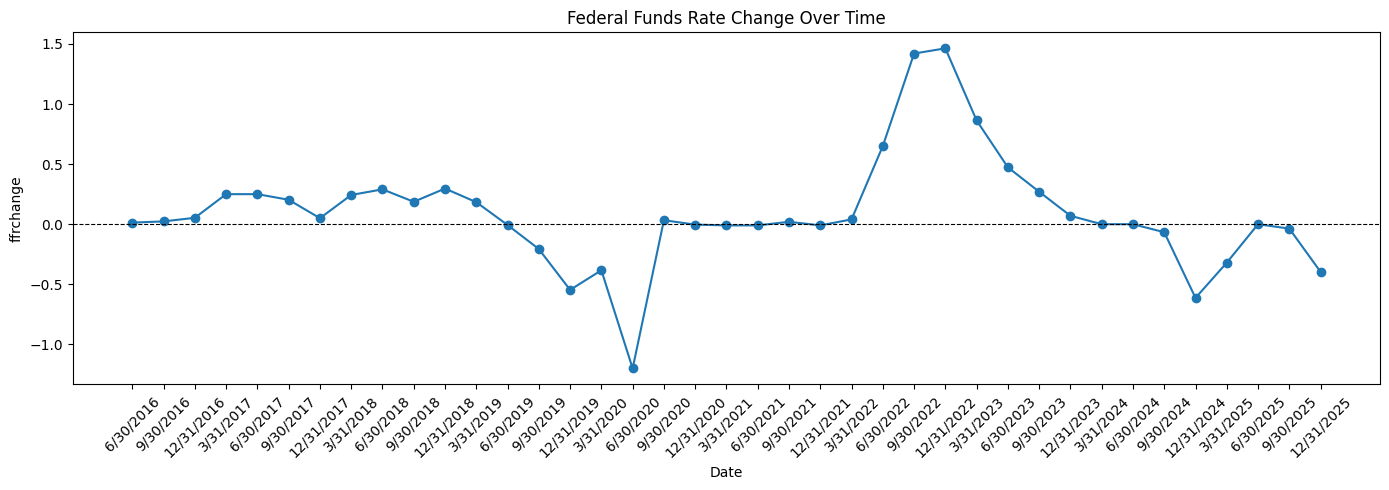

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 读取数据
df = pd.read_csv("/content/deposit_beta_data.csv")

# 把每个银行每个季度的ffrchange去重（因为所有银行同一季度的ffrchange是一样的）
df_ffr = df.drop_duplicates(subset=["date"])[["date", "ffrchange"]].dropna()

# 画图
plt.figure(figsize=(14, 5))
plt.plot(df_ffr["date"], df_ffr["ffrchange"], marker="o", linewidth=1.5)
plt.axhline(y=0, color="black", linewidth=0.8, linestyle="--")  # 零轴参考线
plt.xticks(rotation=45)
plt.title("Federal Funds Rate Change Over Time")
plt.xlabel("Date")
plt.ylabel("ffrchange")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from linearmodels.panel import PanelOLS

# ============================================================
# 第1步：读取数据
# ============================================================
df = pd.read_csv("/content/deposit_beta_data.csv")

# Convert 'date' column to datetime objects (FIX: Added this line)
df['date'] = pd.to_datetime(df['date'])

print("数据形状:", df.shape)
print(df.head())


# ============================================================
# 第2步：建hiking/cutting/pause虚拟变量
# ============================================================
df["hiking"] = (df["ffrchange"] > 0.1).astype(int)
df["cutting"] = (df["ffrchange"] < -0.1).astype(int)
df["pause"]  = (df["ffrchange"].between(-0.1, 0.1)).astype(int)

print("\n各regime季度分布:")
print(f"hiking: {df.drop_duplicates('date')['hiking'].sum()} number of quarters")
print(f"cutting: {df.drop_duplicates('date')['cutting'].sum()} number of quarters")
print(f"pause: {df.drop_duplicates('date')['pause'].sum()} number of quarters")

# Set panel structure (FIX: Recreated df_panel from the updated df)
df_panel = df.set_index(["IDRSSD", "date"])

# ============================================================
# 第3步：Regime模型（hiking/cutting/pause）
# ============================================================
formula_regime = """
depositratechange ~
    ffrchange:hiking + ffrchange:cutting + ffrchange:pause +
    lassetslag + niblag + roalag + leveragelag + loanlag + liquiditylag +
    ffrchange:hiking:lassetslag + ffrchange:hiking:niblag + ffrchange:hiking:roalag +
    ffrchange:hiking:leveragelag + ffrchange:hiking:loanlag + ffrchange:hiking:liquiditylag +
    ffrchange:cutting:lassetslag + ffrchange:cutting:niblag + ffrchange:cutting:roalag +
    ffrchange:cutting:leveragelag + ffrchange:cutting:loanlag + ffrchange:cutting:liquiditylag +
    ffrchange:pause:lassetslag + ffrchange:pause:niblag + ffrchange:pause:roalag +
    ffrchange:pause:leveragelag + ffrchange:pause:loanlag + ffrchange:pause:liquiditylag
"""

model_regime = PanelOLS.from_formula(
    formula_regime,
    data=df_panel
).fit(cov_type="clustered", cluster_entity=True)

print("\n========== Regime模型结果 ==========")
print(model_regime.summary)

数据形状: (167560, 19)
   IDRSSD       date  year  qtr  depositrate  depositratechange  ffrchange  \
0      37 2016-03-31  2016    1     0.486293                NaN        NaN   
1      37 2016-06-30  2016    2     0.482673          -0.003619   0.013333   
2      37 2016-09-30  2016    3     0.493125           0.010451   0.023333   
3      37 2016-12-31  2016    4     0.463422          -0.029703   0.053333   
4      37 2017-03-31  2017    1     0.421112          -0.042310   0.250000   

     lassets  lassetslag       nib    niblag       roa    roalag  leverage  \
0  11.370198         NaN  0.203605       NaN  0.885823       NaN  0.236496   
1  11.365411   11.370198  0.220452  0.203605  1.349018  0.885823  0.244341   
2  11.349783   11.365411  0.214083  0.220452  1.130116  1.349018  0.249297   
3  11.357873   11.349783  0.207518  0.214083  1.349884  1.130116  0.233217   
4  11.359868   11.357873  0.229618  0.207518  0.922991  1.349884  0.167688   

   leveragelag      loan   loanlag  liquidi

In [ ]:
"""
Deposit Beta Analysis — 完整研究代码
导师: Derek Stimel | 学生: Yihan (Linda) Niu

三个模型:
  1. 简化 OLS（hiking/cutting/pause + 控制变量，无交互项）
  2. Stepwise Backward Regression
  3. LASSO Regression


"""

import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# ============================================
# 1. 加载数据
# ============================================
df = pd.read_csv('/content/deposit_beta_data.csv')

# 删除缺失值
df_clean = df.dropna().copy()
print(f"Total effective data number: {len(df_clean)}")
print()

# ============================================
# 2. 创建 hiking / cutting / pause 虚拟变量
# ============================================
df_clean['hiking'] = (df_clean['ffrchange'] > 0).astype(float)
df_clean['cutting'] = (df_clean['ffrchange'] < 0).astype(float)
df_clean['pause']   = (df_clean['ffrchange'] == 0).astype(float)

print(f"hiking  (加息): {df_clean['hiking'].sum():.0f} 条观测")
print(f"cutting (降息): {df_clean['cutting'].sum():.0f} 条观测")
print(f"pause   (不变): {df_clean['pause'].sum():.0f} 条观测")
print()

# 自变量列表（不含交互项）
all_vars = [
    'hiking', 'cutting', 'pause',
    'lassetslag', 'niblag', 'roalag',
    'leveragelag', 'loanlag', 'liquiditylag'
]

y = df_clean['depositratechange']
X = df_clean[all_vars]

# ============================================
# 模型 1: 简化 OLS
# ============================================
print("=" * 70)
print("Model 1: OLS with out Interaction Term")
print("hiking/cutting/pause + control variable but no interaction term")
print("=" * 70)

X1 = sm.add_constant(X)
model1 = sm.OLS(y, X1).fit()
print(model1.summary())

# ============================================
# 模型 2: Stepwise Backward Regression
# ============================================
print("\n" + "=" * 70)
print("Model 2: Stepwise Backward Regression")
print("从全模型开始，逐步剔除 p > 0.05 的变量")
print("=" * 70)

remaining_vars = all_vars.copy()
step = 1

while len(remaining_vars) > 0:
    X_current = sm.add_constant(df_clean[remaining_vars])
    model = sm.OLS(y, X_current).fit()

    pvals = model.pvalues.drop('const')
    max_p = pvals.max()
    worst_var = pvals.idxmax()

    if max_p > 0.05:
        print(f"  第 {step} 步: 剔除 '{worst_var}' (p = {max_p:.6f})")
        remaining_vars.remove(worst_var)
        step += 1
    else:
        break

print(f"\n✅ 最终保留的变量 ({len(remaining_vars)} 个):")
for v in remaining_vars:
    print(f"   - {v}")
print()

X_final = sm.add_constant(df_clean[remaining_vars])
model2 = sm.OLS(y, X_final).fit()
print(model2.summary())

# ============================================
# 模型 3: LASSO Regression
# ============================================
print("\n" + "=" * 70)
print("Model 3: LASSO Regression（L1 正则化 + 交叉验证）")
print("=" * 70)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lasso_cv = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso_cv.fit(X_scaled, y)

print(f"最佳 lambda (alpha): {lasso_cv.alpha_:.6f}")
print(f"R²:                 {lasso_cv.score(X_scaled, y):.4f}")
print()

coef_df = pd.DataFrame({
    'Variable': all_vars,
    'Coefficient': lasso_cv.coef_
})
coef_df['|Coef|'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('|Coef|', ascending=False)
print("LASSO coefficient（按重要性排序）:")
print(coef_df.to_string(index=False))
print(f"截距 (Intercept): {lasso_cv.intercept_:.6f}")

print("\n" + "=" * 70)
print("=" * 70)

Total effective data number: 163371

hiking  (加息): 92158 条观测
cutting (降息): 58646 条观测
pause   (不变): 12567 条观测

Model 1: OLS with out Interaction Term
hiking/cutting/pause + control variable but no interaction term
                            OLS Regression Results                            
Dep. Variable:      depositratechange   R-squared:                       0.124
Model:                            OLS   Adj. R-squared:                  0.124
Method:                 Least Squares   F-statistic:                     2892.
Date:                Tue, 12 May 2026   Prob (F-statistic):               0.00
Time:                        17:30:02   Log-Likelihood:                 49745.
No. Observations:              163371   AIC:                        -9.947e+04
Df Residuals:                  163362   BIC:                        -9.938e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                       

In [ ]:
import pandas as pd
import statsmodels.api as sm

df = pd.read_csv('/content/deposit_beta_data.csv')
df['_dt'] = pd.to_datetime(df['date'])
df = df.dropna().copy()

df['hiking'] = (df['ffrchange'] > 0).astype(float)
df['cutting'] = (df['ffrchange'] < 0).astype(float)
df['pause'] = (df['ffrchange'] == 0).astype(float)

all_vars = ['hiking', 'cutting', 'pause',
            'lassetslag', 'niblag', 'roalag',
            'leveragelag', 'loanlag', 'liquiditylag']

for name, mask in [("2016-2021", (df['_dt'] >= '2016') & (df['_dt'] <= '2021')),
                   ("2022-2025", df['_dt'] >= '2022')]:
    sub = df[mask]
    model = sm.OLS(sub['depositratechange'],
                   sm.add_constant(sub[all_vars])).fit()
    print(f"\n=== {name} (n={len(sub):,}) ===")
    print(model.summary())



=== 2016-2021 (n=79,591) ===
                            OLS Regression Results                            
Dep. Variable:      depositratechange   R-squared:                       0.076
Model:                            OLS   Adj. R-squared:                  0.076
Method:                 Least Squares   F-statistic:                     939.7
Date:                Tue, 12 May 2026   Prob (F-statistic):               0.00
Time:                        18:17:00   Log-Likelihood:                 56891.
No. Observations:               79591   AIC:                        -1.138e+05
Df Residuals:                   79583   BIC:                        -1.137e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0

In [ ]:
"""
2022-2025 子样本 LASSO（连续 FFR + 方向交互项）
不砍成 0/1 方向变量，保留 FFR 变化幅度信息
"""

import pandas as pd
import numpy as np
from sklearn.linear_model import LassoCV, Lasso
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# ============================================
# 1. 加载 + 清理
# ============================================
df = pd.read_csv('/content/deposit_beta_data.csv')           # <-- 改成你的文件名
df['_dt'] = pd.to_datetime(df['date'])
df = df.dropna().copy()

# 方向标志（只用来做交互）
df['hiking']  = (df['ffrchange'] > 0).astype(float)
df['cutting'] = (df['ffrchange'] < 0).astype(float)

# ============================================
# 2. 切 2022-2025 子样本
# ============================================
mask = df['_dt'] >= '2022-01-01'
sub = df[mask].copy()

# ============================================
# 3. 构造自变量（连续 FFR + 方向交互）
# ============================================
# 核心变量：FFR 实际变化大小 × 方向 = 区分"温和加息"和"暴力加息"
sub['ffr_hiking']  = sub['ffrchange'] * sub['hiking']    # 加息时为正值, 否则 0
sub['ffr_cutting'] = sub['ffrchange'] * sub['cutting']   # 降息时为负值, 否则 0
sub['ffr_pause']   = (sub['ffrchange'] == 0).astype(float)

# 控制变量列表
controls = ['lassetslag', 'niblag', 'roalag',
            'leveragelag', 'loanlag', 'liquiditylag']

# 最终变量集
all_vars = ['ffr_hiking', 'ffr_cutting', 'ffr_pause'] + controls

y = sub['depositratechange']
X = sub[all_vars]

# ============================================
# 4. LASSO（标准化 + 5折 CV）
# ============================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lasso_cv = LassoCV(cv=5, random_state=42, max_iter=20000)
lasso_cv.fit(X_scaled, y)

print("=" * 60)
print("  2022-2025 LASSO (连续 FFR + 方向交互)")
print("=" * 60)
print(f"  观测: {len(sub):,}")
print(f"  CV 最优 lambda: {lasso_cv.alpha_:.8f}")
print(f"  R^2: {lasso_cv.score(X_scaled, y):.4f}")
print()

# 系数表
coef_df = pd.DataFrame({
    'Variable': all_vars,
    'Coef': lasso_cv.coef_
})
coef_df['|Coef|'] = coef_df['Coef'].abs()
coef_df = coef_df.sort_values('|Coef|', ascending=False)

print("  LASSO 系数 (标准化后):")
for _, row in coef_df.iterrows():
    dead = '← 压到零!' if abs(row['Coef']) < 1e-8 else ''
    print(f"    {row['Variable']:>20s} = {row['Coef']:+.6f}  {dead}")

# ============================================
# 5. 变量死亡轨迹（α 从 0 到 1，看谁先死）
# ============================================
print()
print("  α 轨迹 — 变量死亡顺序:")
print(f"  {'alpha':>10s}", end="")
for v in all_vars:
    print(f"  {v:>12s}", end="")
print()

alphas = np.logspace(-6, 0, 25)
for a in alphas:
    l = Lasso(alpha=a, max_iter=20000)
    l.fit(X_scaled, y)
    print(f"  {a:10.6f}", end="")
    for c in l.coef_:
        print(f"  {c:12.4f}", end="")
    print()

# ============================================
# 6. 对比 OLS
# ============================================
import statsmodels.api as sm
print()
X_sm = sm.add_constant(X)
ols = sm.OLS(y, X_sm).fit()
print(f"  OLS R²: {ols.rsquared:.4f}")


  2022-2025 LASSO (连续 FFR + 方向交互)
  观测: 67,024
  CV 最优 lambda: 0.00075420
  R^2: 0.2105

  LASSO 系数 (标准化后):
             ffr_cutting = +0.079747  
              ffr_hiking = +0.054546  
                 loanlag = +0.014448  
               ffr_pause = -0.013386  
            liquiditylag = -0.010576  
                  niblag = -0.007144  
                  roalag = +0.006399  
              lassetslag = +0.002099  
             leveragelag = +0.000000  ← 压到零!

  α 轨迹 — 变量死亡顺序:
       alpha    ffr_hiking   ffr_cutting     ffr_pause    lassetslag        niblag        roalag   leveragelag       loanlag  liquiditylag
    0.000001        0.0548        0.0808       -0.0143        0.0027       -0.0080        0.0071        0.0002        0.0147       -0.0109
    0.000002        0.0548        0.0808       -0.0143        0.0027       -0.0080        0.0071        0.0002        0.0147       -0.0109
    0.000003        0.0548        0.0808       -0.0143        0.0027       -0.0080        0.0071    